In [ ]:
# 1. Clonar repositorios
!git clone https://github.com/pedrozudo/ProbabilisticNeuralCircuits.git


Cloning into 'ProbabilisticNeuralCircuits'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 38 (delta 11), reused 35 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 17.43 KiB | 5.81 MiB/s, done.
Resolving deltas: 100% (11/11), done.


# 1. SETUP DE ENTORNO (CRISP-DM: Preparación)

In [ ]:

import sys
import os
import time
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,  classification_report



# Asegurar que Python vea el paquete de circuitos de Zuidberg

PNC_PATH = '/content/ProbabilisticNeuralCircuits'
if PNC_PATH not in sys.path:
    sys.path.append(PNC_PATH)

from circuits.pncrc import GenDisPNCRC

print(f"PyTorch Version: {torch.__version__}")
# Detectar si hay GPU disponible (Acelerará el PNC dramáticamente)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de entrenamiento: {device}")

PyTorch Version: 2.10.0+cu128
Dispositivo de entrenamiento: cuda


# 2. DATA PIPELINE (CRISP-DM: Data Preparation)

In [ ]:
# ==========================================
# BLOQUE 1: Configuración de Datos Fashion-MNIST y K-Fold
# ==========================================
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold

class PNCDataPipelineFashionKFold:
    def __init__(self, batch_size=128, data_dir='./data'):
        self.batch_size = batch_size

        # Agregamos la normalización oficial de Fashion-MNIST
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.2860,), (0.3530,))
        ])

        # Etiquetas para referencia en el análisis posterior
        self.class_names = [
            'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
            'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
        ]

        # --- CAMBIO CLAVE: datasets.FashionMNIST ---
        self.train_set_full = datasets.FashionMNIST(data_dir, train=True, download=True, transform=self.transform)
        self.test_set_full = datasets.FashionMNIST(data_dir, train=False, download=True, transform=self.transform)

    def get_fold_loaders(self, train_idx, val_idx):
        """Genera los DataLoaders dinámicos para un fold específico."""
        train_sub = Subset(self.train_set_full, train_idx)
        val_sub = Subset(self.train_set_full, val_idx)

        train_loader = DataLoader(train_sub, batch_size=self.batch_size, shuffle=True)
        val_loader = DataLoader(val_sub, batch_size=self.batch_size, shuffle=False)

        return train_loader, val_loader

    def get_test_loader(self):
        """Retorna el DataLoader estático de Test para la evaluación final."""
        return DataLoader(self.test_set_full, batch_size=self.batch_size, shuffle=False)

# --- INICIALIZACIÓN DEL ESPACIO DE TRABAJO ---
pipeline_fashion = PNCDataPipelineFashionKFold(batch_size=128)

# Instanciamos el K-Fold garantizando reproducibilidad
K_FOLDS = 5
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

print(f"--- FASHION-MNIST (K-FOLD) PREPARADO PARA PNC ---")
print(f"Dataset de entrenamiento total para K-Fold: {len(pipeline_fashion.train_set_full)} muestras.")
print(f"Dataset de prueba reservado (Test): {len(pipeline_fashion.test_set_full)} muestras.")
print(f"Clases a predecir: {pipeline_fashion.class_names}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.67MB/s]

--- FASHION-MNIST (K-FOLD) PREPARADO PARA PNC ---
Dataset de entrenamiento total para K-Fold: 60000 muestras.
Dataset de prueba reservado (Test): 10000 muestras.
Clases a predecir: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


# 3. MODELADO PNC (CRISP-DM: Modeling)

In [ ]:
import itertools
import torch
import torch.optim as optim
import torch.nn as nn

# ==========================================
# 1. DEFINICIÓN DEL ESPACIO DE BÚSQUEDA (Fashion-MNIST)
# ==========================================
# Constantes arquitectónicas de la Tesis
HEIGHT = 28
WIDTH = 28
N_CLASSES = 10        # 10 clases de ropa
MIXING = 'sum'        # Nodos mezcla estándar para garantizar tractabilidad

# Variables del Grid Search
param_grid = {
    'components': [10, 20, 30],  # Aumentamos capacidad debido a la complejidad de texturas
    'lr': [0.001, 0.0005]        # LR reducido, ideal para la convergencia suave con Adam
}

# Generar todas las combinaciones posibles matemáticamente (Producto Cartesiano)
keys, values = zip(*param_grid.items())
grid_configs = [dict(zip(keys, v)) for v in itertools.product(*values)]

print("--- ESPACIO DE BÚSQUEDA DE HIPERPARÁMETROS (FASHION-MNIST) ---")
print(f"Total de arquitecturas PNC a evaluar: {len(grid_configs)}")
for i, config in enumerate(grid_configs):
    print(f" Configuración {i+1}: Componentes={config['components']}, LR={config['lr']} (Optimizador: Adam)")

# ==========================================
# 2. FUNCIÓN DE INSTANCIACIÓN DINÁMICA (FACTORY)
# ==========================================
def crear_modelo_y_optimizador_fashion(config, device):
    """
    Instancia una arquitectura PNC y su optimizador Adam completamente nuevos
    basados en la configuración del Grid Search para Fashion-MNIST.
    """
    modelo_pnc = GenDisPNCRC(
        height=HEIGHT,
        width=WIDTH,
        components=config['components'],
        n_classes=N_CLASSES,
        mixing=MIXING
    ).to(device)

    # <-- CAMBIO METODOLÓGICO: Usamos Adam con el LR dictado por el Grid Search
    optimizer_pnc = optim.Adam(
        modelo_pnc.parameters(),
        lr=config['lr']
    )

    criterion = nn.CrossEntropyLoss()

    # Cálculo de parámetros para justificar la eficiencia espacial en la Tesis
    total_params = sum(p.numel() for p in modelo_pnc.parameters() if p.requires_grad)

    return modelo_pnc, optimizer_pnc, criterion, total_params

# --- PRUEBA DE LA FÁBRICA DE MODELOS ---
# Simulamos instanciar la primera configuración para verificar que no haya errores
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mod_prueba, opt_prueba, crit_prueba, params_prueba = crear_modelo_y_optimizador_fashion(grid_configs[0], device)

print(f"\n[Verificación Exitosa] Arquitectura PNC instanciada con Configuración 1.")
print(f"Total de parámetros entrenables: {params_prueba:,}")

--- ESPACIO DE BÚSQUEDA DE HIPERPARÁMETROS (FASHION-MNIST) ---
Total de arquitecturas PNC a evaluar: 6
 Configuración 1: Componentes=10, LR=0.001 (Optimizador: Adam)
 Configuración 2: Componentes=10, LR=0.0005 (Optimizador: Adam)
 Configuración 3: Componentes=20, LR=0.001 (Optimizador: Adam)
 Configuración 4: Componentes=20, LR=0.0005 (Optimizador: Adam)
 Configuración 5: Componentes=30, LR=0.001 (Optimizador: Adam)
 Configuración 6: Componentes=30, LR=0.0005 (Optimizador: Adam)

[Verificación Exitosa] Arquitectura PNC instanciada con Configuración 1.
Total de parámetros entrenables: 312,200


# 4. ENTRENAMIENTO Y EVALUACIÓN (CRISP-DM: Evaluation)

In [ ]:
# ==========================================
# BLOQUE 3: Entrenamiento K-Fold + Grid Search (Fashion-MNIST)
# ==========================================
import time
import pandas as pd
import os
import torch

os.makedirs('/content/resultados', exist_ok=True)
os.makedirs('/content/modelos_tesis', exist_ok=True)

EPOCHS = 10
# Usamos una lista global para mantener el formato 'Tidy' tabular
historial_global_fashion = []

mejor_accuracy_global = 0.0
mejor_config_global = None
ruta_mejor_modelo = '/content/modelos_tesis/mejor_pnc_fashion.pth'

print("\n--- INICIANDO ENTRENAMIENTO PNC FASHION-MNIST (GRID SEARCH + K-FOLD) ---")

for idx_config, config in enumerate(grid_configs):
    print(f"\n[{idx_config+1}/{len(grid_configs)}] Evaluando Config: Componentes={config['components']}, LR={config['lr']}")

    for fold, (train_idx, val_idx) in enumerate(kf.split(pipeline_fashion.train_set_full)):
        print(f"  -> Iniciando Fold {fold + 1}/{K_FOLDS}...")

        # 1. Cargar datos dinámicos del fold
        train_loader, val_loader = pipeline_fashion.get_fold_loaders(train_idx, val_idx)

        # 2. Instanciar modelo SOTA desde cero
        modelo_pnc, optimizer_pnc, criterion, total_params = crear_modelo_y_optimizador_fashion(config, device)

        for epoch in range(EPOCHS):
            epoch_time_start = time.time()

            # --- FASE DE ENTRENAMIENTO ---
            modelo_pnc.train()
            train_loss, train_correct, train_total = 0.0, 0, 0

            for data, target in train_loader:
                data = data.squeeze(1).to(device)

                # --- TU PROTECCIÓN CRÍTICA ---
                data = torch.clamp(data, 0.0, 1.0)
                data = data * 255.0

                target = target.to(device)
                optimizer_pnc.zero_grad()

                log_probs = modelo_pnc(data)
                loss = criterion(log_probs, target)

                # Prevención de colapso por NaNs
                if torch.isnan(loss):
                    continue

                loss.backward()

                # Gradient Clipping para circuitos probabilísticos
                torch.nn.utils.clip_grad_norm_(modelo_pnc.parameters(), max_norm=1.0)

                optimizer_pnc.step()

                train_loss += loss.item() * data.size(0)
                _, predicted = log_probs.max(1)
                train_total += target.size(0)
                train_correct += predicted.eq(target).sum().item()

            # --- FASE DE VALIDACIÓN ---
            modelo_pnc.eval()
            val_loss, val_correct, val_total = 0.0, 0, 0

            with torch.no_grad():
                for data, target in val_loader:
                    data = data.squeeze(1).to(device)
                    # El mismo clamp para mantener coherencia
                    data = torch.clamp(data, 0.0, 1.0) * 255.0
                    target = target.to(device)

                    log_probs = modelo_pnc(data)
                    loss = criterion(log_probs, target)

                    if not torch.isnan(loss):
                        val_loss += loss.item() * data.size(0)

                    _, predicted = log_probs.max(1)
                    val_total += target.size(0)
                    val_correct += predicted.eq(target).sum().item()

            # --- REGISTRO DE MÉTRICAS ---
            epoch_time = time.time() - epoch_time_start

            # Tu prevención de división por cero
            if train_total > 0 and val_total > 0:
                avg_train_loss = train_loss / train_total
                train_acc = train_correct / train_total
                avg_val_loss = val_loss / val_total
                val_acc = val_correct / val_total

                # Guardado multidimensional
                registro = {
                    'config_id': idx_config + 1,
                    'components': config['components'],
                    'lr': config['lr'],
                    'fold': fold + 1,
                    'epoch': epoch + 1,
                    'train_loss': avg_train_loss,
                    'train_acc': train_acc,
                    'val_loss': avg_val_loss,
                    'val_acc': val_acc,
                    'epoch_time_seconds': epoch_time,
                    'total_params': total_params
                }
                historial_global_fashion.append(registro)

            # Imprimir solo la última época por fold para consola limpia
            if (epoch + 1) == EPOCHS:
                print(f"     Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Time: {epoch_time:.2f}s")

        # --- LÓGICA DEL MEJOR MODELO ---
        if val_acc > mejor_accuracy_global:
            mejor_accuracy_global = val_acc
            mejor_config_global = config
            torch.save(modelo_pnc.state_dict(), ruta_mejor_modelo)
            print(f"     [!] NUEVO CAMPEÓN: Guardando pesos (Val Acc: {val_acc:.4f})")

# ==========================================
# 5. EXPORTACIÓN PARA EL NOTEBOOK 3
# ==========================================
df_pnc_fashion = pd.DataFrame(historial_global_fashion)
df_pnc_fashion.to_csv('/content/resultados/pnc_kfold_fashion_history.csv', index=False)

print("\n=======================================================")
print(f"ENTRENAMIENTO FASHION-MNIST FINALIZADO.")
print(f"Mejor Configuración: {mejor_config_global}")
print(f"Mejor Exactitud (Validation): {mejor_accuracy_global:.4f}")
print("Resultados exportados a '/content/resultados/pnc_kfold_fashion_history.csv'")
print("=======================================================")


--- INICIANDO ENTRENAMIENTO PNC FASHION-MNIST (GRID SEARCH + K-FOLD) ---

[1/6] Evaluando Config: Componentes=10, LR=0.001
  -> Iniciando Fold 1/5...
     Epoch 10/10 | Train Acc: 0.8354 | Val Acc: 0.8211 | Time: 56.26s
     [!] NUEVO CAMPEÓN: Guardando pesos (Val Acc: 0.8211)
  -> Iniciando Fold 2/5...
     Epoch 10/10 | Train Acc: 0.8352 | Val Acc: 0.8283 | Time: 56.14s
     [!] NUEVO CAMPEÓN: Guardando pesos (Val Acc: 0.8283)
  -> Iniciando Fold 3/5...
     Epoch 10/10 | Train Acc: 0.8367 | Val Acc: 0.8244 | Time: 56.24s
  -> Iniciando Fold 4/5...
     Epoch 10/10 | Train Acc: 0.8354 | Val Acc: 0.8247 | Time: 56.09s
  -> Iniciando Fold 5/5...
     Epoch 10/10 | Train Acc: 0.8361 | Val Acc: 0.8198 | Time: 56.11s

[2/6] Evaluando Config: Componentes=10, LR=0.0005
  -> Iniciando Fold 1/5...
     Epoch 10/10 | Train Acc: 0.8330 | Val Acc: 0.8210 | Time: 56.94s
  -> Iniciando Fold 2/5...
     Epoch 10/10 | Train Acc: 0.8315 | Val Acc: 0.8263 | Time: 56.66s
  -> Iniciando Fold 3/5...
   

Generando predicciones del PNC para Fashion-MNIST (Set de prueba)...


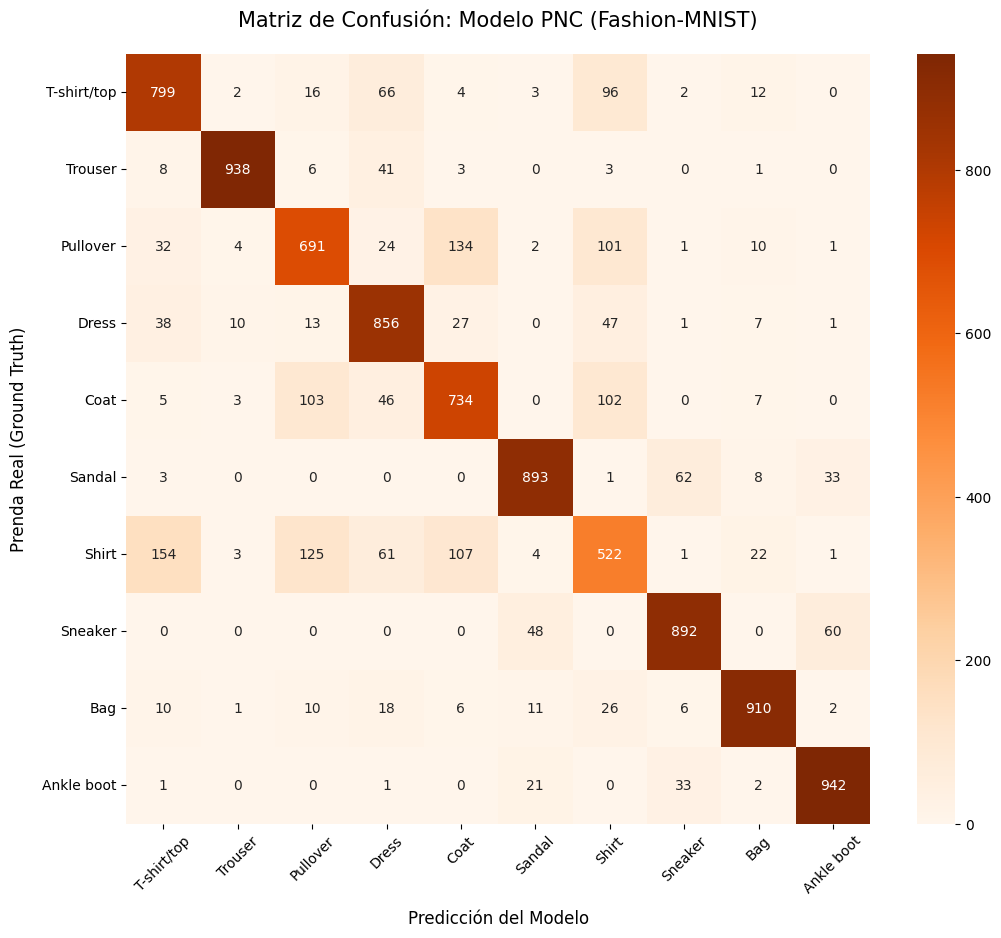

Matriz del PNC (Fashion) guardada en: /content/graficas_tesis/matriz_confusion_pnc_fashion.png


In [ ]:

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# 2. Obtener predicciones (Modo Evaluación)
modelo_pnc.eval()
todas_las_preds = []
todas_las_etiquetas = []

print("Generando predicciones del PNC para Fashion-MNIST (Set de prueba)...")
with torch.no_grad():
    for data, target in test_loader:
        # --- BLINDAJE NUMÉRICO ---
        # Aplicamos exactamente el mismo pre-procesamiento que en el entrenamiento estable
        data = data.squeeze(1).to(device)
        data = torch.clamp(data, 0.0, 1.0) * 255.0

        output = modelo_pnc(data)
        _, preds = torch.max(output, 1)

        todas_las_preds.extend(preds.cpu().numpy())
        todas_las_etiquetas.extend(target.numpy())

# 3. Calcular la matriz
cm_pnc = confusion_matrix(todas_las_etiquetas, todas_las_preds)


plt.figure(figsize=(12, 10))

sns.heatmap(cm_pnc, annot=True, fmt='d', cmap='Oranges', cbar=True,
            xticklabels=class_names, yticklabels=class_names)

plt.title('Matriz de Confusión: Modelo PNC (Fashion-MNIST)', fontsize=15, pad=20)
plt.xlabel('Predicción del Modelo', fontsize=12, labelpad=10)
plt.ylabel('Prenda Real (Ground Truth)', fontsize=12, labelpad=10)


plt.xticks(rotation=45)
plt.yticks(rotation=0)

# 5. Guardar para la comparativa de la tesis
os.makedirs('/content/graficas_tesis', exist_ok=True)
ruta_cm_pnc = '/content/graficas_tesis/matriz_confusion_pnc_fashion.png'
plt.savefig(ruta_cm_pnc, dpi=300, bbox_inches='tight')
plt.show()

print(f"Matriz del PNC (Fashion) guardada en: {ruta_cm_pnc}")

In [ ]:


# 1. Generar reportes como diccionarios
#report_kdm = classification_report(y_test, y_pred, output_dict=True)
report_pnc = classification_report(todas_las_etiquetas, todas_las_preds, output_dict=True)

# 2. Extraer métricas globales (Weighted Avg)
data = {
    'Métrica': ['Precision', 'Recall', 'F1-Score', 'Accuracy'],

    'PNC (Circuito Probabilístico)': [
        report_pnc['weighted avg']['precision'],
        report_pnc['weighted avg']['recall'],
        report_pnc['weighted avg']['f1-score'],
        report_pnc['accuracy']
    ]
}
"""
'KDM (Inspiración Cuántica)': [
        report_kdm['weighted avg']['precision'],
        report_kdm['weighted avg']['recall'],
        report_kdm['weighted avg']['f1-score'],
        report_kdm['accuracy']
    ]


"""
# 3. Crear DataFrame y mostrar
df_comparativo = pd.DataFrame(data)
print("--- TABLA COMPARATIVA DE RENDIMIENTO FINAL ---")
print(df_comparativo.to_string(index=False))

# Opcional: Guardar como CSV para tu Excel de la tesis
df_comparativo.to_csv('/content/resultados/tabla_comparativa_final.csv', index=False)

--- TABLA COMPARATIVA DE RENDIMIENTO FINAL ---
  Métrica  PNC (Circuito Probabilístico)
Precision                       0.816581
   Recall                       0.817700
 F1-Score                       0.816583
 Accuracy                       0.817700
